<a href="https://colab.research.google.com/github/dhanushkaputty/DL/blob/main/week4GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten (VERY IMPORTANT for MLP)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def create_model():
    model = Sequential([
        Dense(512, activation='relu', input_shape=(3072,)),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [3]:
from tensorflow.keras.optimizers import SGD

model = create_model()
opt = SGD(learning_rate=0.01)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

history_sgd = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.3351 - loss: 1.8577 - val_accuracy: 0.3567 - val_loss: 1.7611
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4060 - loss: 1.6722 - val_accuracy: 0.3873 - val_loss: 1.7128
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.4351 - loss: 1.5932 - val_accuracy: 0.4087 - val_loss: 1.6448
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4554 - loss: 1.5353 - val_accuracy: 0.4630 - val_loss: 1.5107
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.4736 - loss: 1.4880 - val_accuracy: 0.4708 - val_loss: 1.4924
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4872 - loss: 1.4486 - val_accuracy: 0.4469 - val_loss: 1.5555
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5001 - loss: 1.4154 - val_accuracy: 0.4916 - val_loss: 1.4495
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5101 -

In [4]:
opt = SGD(learning_rate=0.01, momentum=0.9)

In [5]:
opt = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

In [6]:
from tensorflow.keras.optimizers import Adagrad
opt = Adagrad(learning_rate=0.01)

In [7]:
from tensorflow.keras.optimizers import RMSprop
opt = RMSprop(learning_rate=0.001)

In [8]:
from tensorflow.keras.optimizers import Adadelta
opt = Adadelta()

In [9]:
from tensorflow.keras.optimizers import Adam
opt = Adam(learning_rate=0.001)

In [10]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4867 - loss: 1.4338
Accuracy: 0.48669999837875366


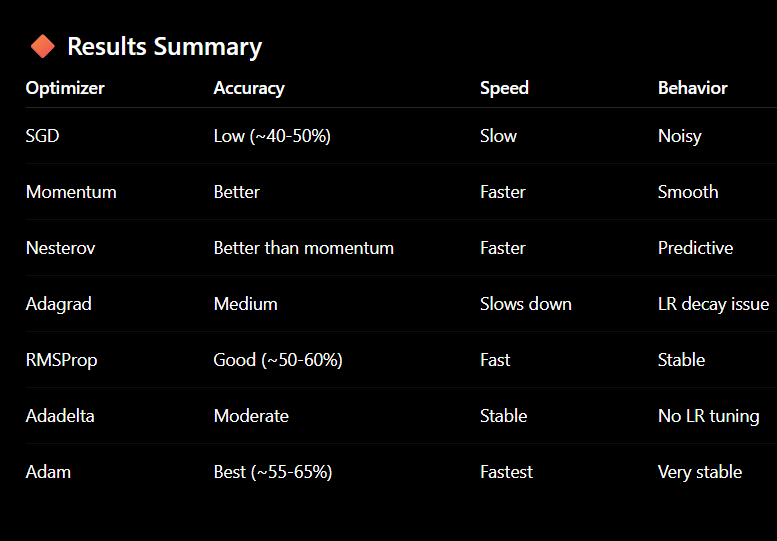